In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [246]:
Development = pd.read_csv("../Dataset/HDI.csv", encoding="latin1")

Development.head()

,Country,Region,Human Development Index (HDI),Life expectancy,Expected years of schooling YEARS,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank 2022,HDI rank 2021
0,Switzerland,Very High Human Development,0.967,84.3,16.6,13.9,"69,433",6.0,1.0,1.0
1,Norway,Very High Human Development,0.966,83.4,18.6,13.1,"69,190",6.0,2.0,2.0
2,Iceland,Very High Human Development,0.959,82.8,19.1,13.8,"54,688",16.0,3.0,4.0
3,"Hong Kong, China (SAR)",Very High Human Development,0.956,84.3,17.8,12.3,"62,486",6.0,4.0,3.0
4,Denmark,Very High Human Development,0.952,81.9,18.8,13.0,"62,019",6.0,5.0,8.0


In [247]:
Development.shape

(195, 10)

In [248]:
Development.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     195 non-null    str    
 1   Region                                     195 non-null    str    
 2   HDI              193 non-null    float64
 3   Life expectancy              195 non-null    float64
 4   Expected years of schooling YEARS           194 non-null    float64
 5   Mean years of schooling               193 non-null    float64
 6   Gross national income (GNI) per capita  193 non-null    str    
 7   GNI per capita rank minus HDI rank          193 non-null    float64
 8   HDI rank 2022                               193 non-null    float64
 9   HDI rank 2021                               192 non-null    float64
dtypes: float64(7), str(3)
memory usage: 15.4 KB


In [249]:
Development.isnull().sum()

Country                                       0
Region                                       0
HDI                2
Life expectancy                0
Expected years of schooling YEARS             1
Mean years of schooling                 2
Gross national income (GNI) per capita    2
GNI per capita rank minus HDI rank            2
HDI rank 2022                                 2
HDI rank 2021                                 3
dtype: int64

In [250]:
le = LabelEncoder()

Development["Region"] = le.fit_transform(Development["Region"])

In [251]:
Development["Gross national income (GNI) per capita"] = (
    Development["Gross national income (GNI) per capita"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

Development["Gross national income (GNI) per capita"] = pd.to_numeric(
    Development["Gross national income (GNI) per capita"],
    errors="coerce"
)

In [256]:
X = Development[
    [
        "Region",
        "Life expectancy",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

y = Development["HDI"]

# Convert target to numeric
y = pd.to_numeric(y, errors="coerce")

In [257]:
from sklearn.impute import SimpleImputer

# Fill missing values in X
imputer = SimpleImputer(strategy="mean")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Remove rows where y is missing
mask = y.notna()

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

In [258]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [259]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [260]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [261]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)
    print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 0.13024032851091275
Mean Squared Error (MSE): 0.02400076309063341
Root Mean Squared Error (RMSE): 0.15492179669314904
R2 Score: -0.2597961413741947


In [263]:
import numpy as np

result = pd.DataFrame({
    "Actual HDI": np.array(y_test).ravel(),
    "Predicted HDI": np.array(y_pred).ravel()
})

result.head(10)

,Actual HDI,Predicted HDI
0,0.855,0.652978
1,0.624,0.721969
2,0.781,0.703402
3,0.602,0.630598
4,0.708,0.705276
5,0.569,0.699749
6,0.939,0.712255
7,0.929,0.704241
8,0.937,0.635423
9,0.946,0.673964


In [264]:
import numpy as np

result = pd.DataFrame({
    "Actual HDI": np.array(y_test).ravel(),
    "Predicted HDI": np.array(y_pred).ravel()
})

result.head(10)

,Actual HDI,Predicted HDI
0,0.855,0.652978
1,0.624,0.721969
2,0.781,0.703402
3,0.602,0.630598
4,0.708,0.705276
5,0.569,0.699749
6,0.939,0.712255
7,0.929,0.704241
8,0.937,0.635423
9,0.946,0.673964


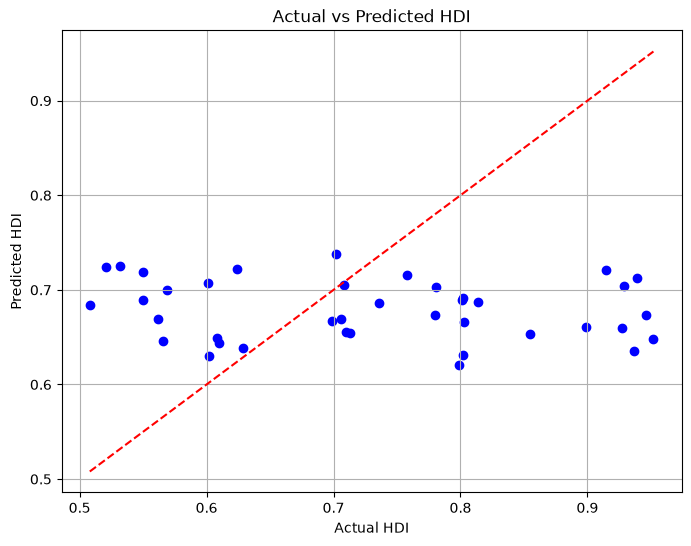

In [265]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(np.array(y_test).flatten(),
            np.array(y_pred).flatten(),
            color="blue")

plt.plot(
    [min(np.array(y_test).flatten()), max(np.array(y_test).flatten())],
    [min(np.array(y_test).flatten()), max(np.array(y_test).flatten())],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual HDI")
plt.ylabel("Predicted HDI")
plt.title("Actual vs Predicted HDI")
plt.grid(True)

plt.show()

In [266]:
sample = pd.DataFrame({
    "Region": [3],
    "Life expectancy": [75],
    "Mean years of schooling": [12],
    "Gross national income (GNI) per capita": [25000]
})

sample = pd.DataFrame(
    imputer.transform(sample),
    columns=sample.columns
)

prediction = model.predict(sample)

print("Predicted HDI:", prediction[0])

Predicted HDI: 0.8361076338512046


In [267]:
import joblib

joblib.dump(model, "../Flask/hdi_model.pkl")

print("Model saved successfully!")

Model saved successfully!
